# State Electricity Generation Analysis, 1990-2024

How has each U.S. state changed their green energy generation over the last three decades?

This notebook takes net generation data from the EIA, categorizes each fuel source as green or non-green, 
and shows how each U.S. state has shifted toward green electricity from 1990 to 2024. 

The data output is fed to a Power BI dashboard to visualize the information.

**Green energy** (or renewable energy) is considered: Nuclear, Hydroelectric, Wind, Solar, Geothermal,
Wood, and Other Biomass. 

**Non-green energy** is considered: Coal, Natural Gas, Petroleum, and Other Gases. (Note: biomass is counted as green by renewability, but it does emit CO2)

Data source: EIA, Annual Net Generation by State
(https://www.eia.gov/electricity/data/state/)

In [9]:
import sys
!{sys.executable} -m pip install openpyxl

## 1. Loading the data

The EIA provided data has a junk banner on the first row.

In [10]:
import pandas as pd

raw = pd.read_excel("annual_generation_state.xls", header=None, nrows=10)

for i, row in raw.iterrows():
    print(i, list(row.values))

0 ['State Historical Tables for 2024\nReleased: September 2025\nNext Update: October 2026', nan, nan, nan, nan]
1 ['YEAR', 'STATE', 'TYPE OF PRODUCER', 'ENERGY SOURCE', 'GENERATION (Megawatthours)']
2 [1990, 'AK', 'Total Electric Power Industry', 'Total', 5599506]
3 [1990, 'AK', 'Total Electric Power Industry', 'Coal', 510573]
4 [1990, 'AK', 'Total Electric Power Industry', 'Hydroelectric Conventional', 974521]
5 [1990, 'AK', 'Total Electric Power Industry', 'Natural Gas', 3466261]
6 [1990, 'AK', 'Total Electric Power Industry', 'Petroleum', 497116]
7 [1990, 'AK', 'Total Electric Power Industry', 'Wind', 0]
8 [1990, 'AK', 'Total Electric Power Industry', 'Wood and Wood Derived Fuels', 151035]
9 [1990, 'AK', 'Electric Generators, Electric Utilities', 'Total', 4493024]


The real header starts at row 1.

In [11]:
gen = pd.read_excel("annual_generation_state.xls", skiprows=1)

gen.info()
gen.head()

<class 'pandas.DataFrame'>
RangeIndex: 64417 entries, 0 to 64416
Data columns (total 5 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   YEAR                        64417 non-null  int64  
 1   STATE                       64417 non-null  str    
 2   TYPE OF PRODUCER            64417 non-null  str    
 3   ENERGY SOURCE               64417 non-null  str    
 4   GENERATION (Megawatthours)  64417 non-null  float64
dtypes: float64(1), int64(1), str(3)
memory usage: 2.5 MB


,YEAR,STATE,TYPE OF PRODUCER,ENERGY SOURCE,GENERATION (Megawatthours)
0,1990,AK,Total Electric Power Industry,Total,5599506.0
1,1990,AK,Total Electric Power Industry,Coal,510573.0
2,1990,AK,Total Electric Power Industry,Hydroelectric Conventional,974521.0
3,1990,AK,Total Electric Power Industry,Natural Gas,3466261.0
4,1990,AK,Total Electric Power Industry,Petroleum,497116.0


## 2. Explore the categories

Before filtering, verify the column data.

In [12]:
print(gen["YEAR"].min(), "to", gen["YEAR"].max())
print()
print(gen["TYPE OF PRODUCER"].unique())
print()
print(gen["ENERGY SOURCE"].unique())

1990 to 2024

<StringArray>
[                   'Total Electric Power Industry',
          'Electric Generators, Electric Utilities',
        'Combined Heat and Power, Industrial Power',
        'Combined Heat and Power, Commercial Power',
 'Electric Generators, Independent Power Producers',
          'Combined Heat and Power, Electric Power']
Length: 6, dtype: str

<StringArray>
[                         'Total',                           'Coal',
     'Hydroelectric Conventional',                    'Natural Gas',
                      'Petroleum',                           'Wind',
    'Wood and Wood Derived Fuels',                        'Nuclear',
                  'Other Biomass',                    'Other Gases',
                 'Pumped Storage',                     'Geothermal',
                          'Other', 'Solar Thermal and Photovoltaic']
Length: 14, dtype: str


## 3. Filter to one energy producer type

The EIA provided data breaks generation down by producer type (utilities, independent producers, etc).
Keep only the "Total Electric Power Industry" to avoid double counting.

In [13]:
gen = gen[gen["TYPE OF PRODUCER"] == "Total Electric Power Industry"]

print(len(gen), "rows remaining")

17622 rows remaining


This is a state analysis, so drop any non-state or blank state codes.

In [14]:
gen = gen[~gen["STATE"].isin(["US-TOTAL", "US-Total", "  ", " "])]

print(sorted(gen["STATE"].unique()))
print(len(gen["STATE"].unique()), "states (50 + DC)")

['AK', 'AL', 'AR', 'AZ', 'CA', 'CO', 'CT', 'DC', 'DE', 'FL', 'GA', 'HI', 'IA', 'ID', 'IL', 'IN', 'KS', 'KY', 'LA', 'MA', 'MD', 'ME', 'MI', 'MN', 'MO', 'MS', 'MT', 'NC', 'ND', 'NE', 'NH', 'NJ', 'NM', 'NV', 'NY', 'OH', 'OK', 'OR', 'PA', 'RI', 'SC', 'SD', 'TN', 'TX', 'UT', 'VA', 'VT', 'WA', 'WI', 'WV', 'WY']
51 states (50 + DC)


## 4. Separate the per-fuel rows

Keep only the "per-fuel" observations to categorize them later. Exclude Pumped Storage and Other as they are not relevant to the analysis.

In [15]:
totals = gen[gen["ENERGY SOURCE"] == "Total"]
fuels = gen[gen["ENERGY SOURCE"] != "Total"]

print(len(fuels), "fuel rows")
print(sorted(fuels["ENERGY SOURCE"].unique()))

fuels = fuels[~fuels["ENERGY SOURCE"].isin(["Pumped Storage", "Other"])]

print(sorted(fuels["ENERGY SOURCE"].unique()))

15344 fuel rows
['Coal', 'Geothermal', 'Hydroelectric Conventional', 'Natural Gas', 'Nuclear', 'Other', 'Other Biomass', 'Other Gases', 'Petroleum', 'Pumped Storage', 'Solar Thermal and Photovoltaic', 'Wind', 'Wood and Wood Derived Fuels']
['Coal', 'Geothermal', 'Hydroelectric Conventional', 'Natural Gas', 'Nuclear', 'Other Biomass', 'Other Gases', 'Petroleum', 'Solar Thermal and Photovoltaic', 'Wind', 'Wood and Wood Derived Fuels']


## 5. Categorize green vs non-green

Categorization of the energy generation sources. Everything in `green_sources` is green; everything else is non-green. This can be adjusted to your liking.

In [16]:
green_sources = [
    "Nuclear",
    "Hydroelectric Conventional",
    "Wind",
    "Solar Thermal and Photovoltaic",
    "Geothermal",
    "Wood and Wood Derived Fuels",
    "Other Biomass",
]

fuels["CATEGORY"] = fuels["ENERGY SOURCE"].apply(
    lambda x: "Green" if x in green_sources else "Non-Green"
)

# Verify the categorization
print(fuels.groupby("CATEGORY")["ENERGY SOURCE"].unique())

CATEGORY
Green        [Hydroelectric Conventional, Wind, Wood and Wo...
Non-Green          [Coal, Natural Gas, Petroleum, Other Gases]
Name: ENERGY SOURCE, dtype: object


## 6. Build the state-year table

Group by year, state, and category to sum generation, then pivot so each state-year is one
row with Green and Non-Green columns. Add TOTAL and GREEN_SHARE.

In [17]:
grouped = (
    fuels.groupby(["YEAR", "STATE", "CATEGORY"])["GENERATION (Megawatthours)"]
    .sum()
    .reset_index()
)

pivot = grouped.pivot_table(
    index=["YEAR", "STATE"],
    columns="CATEGORY",
    values="GENERATION (Megawatthours)",
)

pivot.head()

CATEGORY         Green   Non-Green
YEAR STATE                        
1990 AK      1125556.0   4473950.0
     AL     24565739.0  55086394.0
     AR     16190139.0  22866487.0
     AZ     28123153.0  34401377.0
     CA     80372078.0  84426579.0

There are a few instances of NaN datapoints where no green energy was produced for a given year. Convert NaN to 0.

In [18]:
pivot["Green"] = pivot["Green"].fillna(0)
pivot["Non-Green"] = pivot["Non-Green"].fillna(0)

pivot["TOTAL"] = pivot["Green"] + pivot["Non-Green"]
pivot["GREEN_SHARE"] = pivot["Green"] / pivot["TOTAL"]

pivot = pivot.reset_index()
pivot.columns.name = None

pivot.head()

,YEAR,STATE,Green,Non-Green,TOTAL,GREEN_SHARE
0,1990,AK,1125556.0,4473950.0,5599506.0,0.201010
1,1990,AL,24565739.0,55086394.0,79652133.0,0.308413
2,1990,AR,16190139.0,22866487.0,39056626.0,0.414530
3,1990,AZ,28123153.0,34401377.0,62524530.0,0.449794
4,1990,CA,80372078.0,84426579.0,164798657.0,0.487699


## 7. Analysis #1 - Largest Changes in Green Energy Share

Which states increased the green *share* of their grid the most?

FYI, green energy share = percentage of green energy generation relative to total energy generation.

In [19]:
start = pivot[pivot["YEAR"] == 1990][["STATE", "GREEN_SHARE"]]
end = pivot[pivot["YEAR"] == 2024][["STATE", "GREEN_SHARE"]]

change = start.merge(end, on="STATE", suffixes=("_1990", "_2024"))
change["CHANGE"] = change["GREEN_SHARE_2024"] - change["GREEN_SHARE_1990"]
change = change.sort_values("CHANGE", ascending=False)

change.head(15).style.format({
    "GREEN_SHARE_1990": "{:.1%}",
    "GREEN_SHARE_2024": "{:.1%}",
    "CHANGE": "{:.1%}",
})

,STATE,GREEN_SHARE_1990,GREEN_SHARE_2024,CHANGE
12,IA,13.0%,65.5%,52.6%
32,NM,0.8%,49.4%,48.7%
7,DC,0.0%,46.8%,46.8%
16,KS,23.1%,67.9%,44.9%
20,MD,12.3%,52.7%,40.5%
5,CO,4.4%,41.4%,36.9%
36,OK,6.4%,42.7%,36.3%
28,ND,6.3%,39.6%,33.2%
43,TX,6.8%,36.2%,29.4%
33,NV,12.4%,40.1%,27.7%


Iowa leads, driven by its Wind investments. However, D.C is also in the top, rising from 0% to
~47% over the course of 3 deacdes. D.C is relatively tiny to the other states, so a small amount of solar swings its entire percentage. This is the
limitation of a share-based metric: it over-rewards small states. Hence, a second analysis is needed.

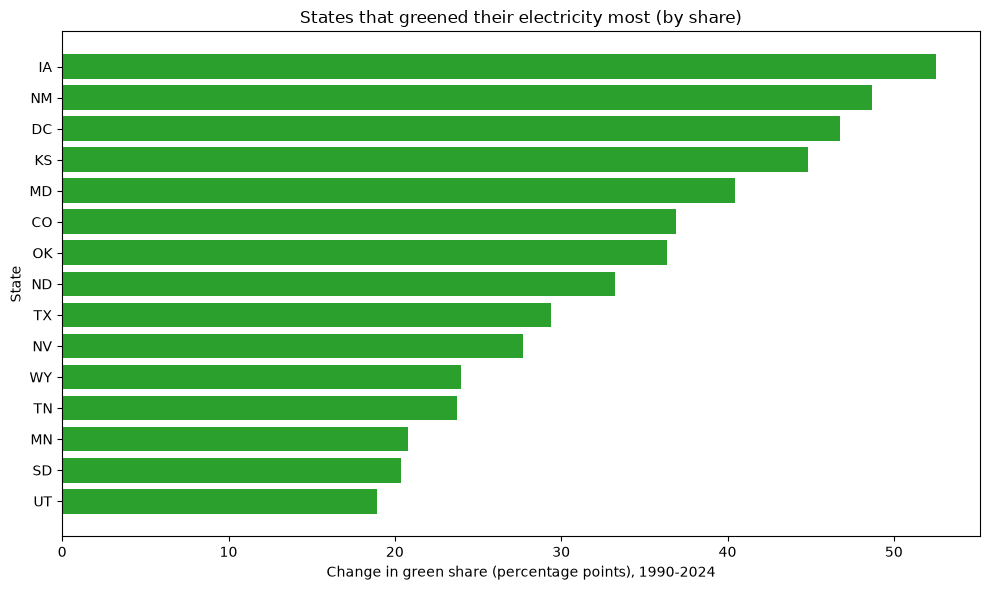

In [20]:
import matplotlib.pyplot as plt

top15 = change.head(15)

plt.figure(figsize=(10, 6))
plt.barh(top15["STATE"], top15["CHANGE"] * 100, color="#2ca02c")
plt.xlabel("Change in green share (percentage points), 1990-2024")
plt.ylabel("State")
plt.title("States that greened their electricity most (by share)")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

## 8. Analysis #2 - Absolute Green Energy (MWh) added

A more honest "impact" metric is how much green energy generation in MWh a state added over the past 3 decades. This can be calculated by taking the green energy generated in 2024 minus the green energy generated in 1990.

In [21]:
green_start = pivot[pivot["YEAR"] == 1990][["STATE", "Green"]]
green_end = pivot[pivot["YEAR"] == 2024][["STATE", "Green"]]

green_change = green_start.merge(green_end, on="STATE", suffixes=("_1990", "_2024"))
green_change["GREEN_ADDED"] = green_change["Green_2024"] - green_change["Green_1990"]
green_change = green_change.sort_values("GREEN_ADDED", ascending=False)

green_change.head(15)

,STATE,Green_1990,Green_2024,GREEN_ADDED
43,TX,19089871.0,205142774.0,186052903.0
14,IL,72186416.0,127478869.0,55292453.0
4,CA,80372078.0,127183099.0,46811021.0
12,IA,3904704.0,46188409.0,42283705.0
36,OK,3001337.0,40191272.0,37189935.0
10,GA,32468777.0,65467836.0,32999059.0
1,AL,24565739.0,57366781.0,32801042.0
16,KS,7887766.0,39196608.0,31308842.0
27,NC,34189230.0,62006480.0,27817250.0
9,FL,25771373.0,50845359.0,25073986.0


From the results, we see that Texas dominates, adding ~186 million MWh of green energy generation, mostly wind. The picture
is now completely different: big states win on absolute impact, small
states win on proportional change.

Let's take a look at the bottom 6 states:

In [22]:
green_change.sort_values("GREEN_ADDED").head(6)

,STATE,Green_1990,Green_2024,GREEN_ADDED
47,WA,94338005.0,81113434.0,-13224571.0
37,OR,48207787.0,39708992.0,-8498795.0
21,ME,12360910.0,7887005.0,-4473905.0
19,MA,7879377.0,4101654.0,-3777723.0
6,CT,21420179.0,18276898.0,-3143281.0
46,VT,5096284.0,2253756.0,-2842528.0


Washington, Oregon, and Maine among others all reduced their green energy generation. These are hydro and nuclear
heavy states - their green energy output was already high in 1990 and has been flat or declining,
while their total generation grew. So their green energy *share* decreased even though they were never heavily invested in non-green energy generation sources.

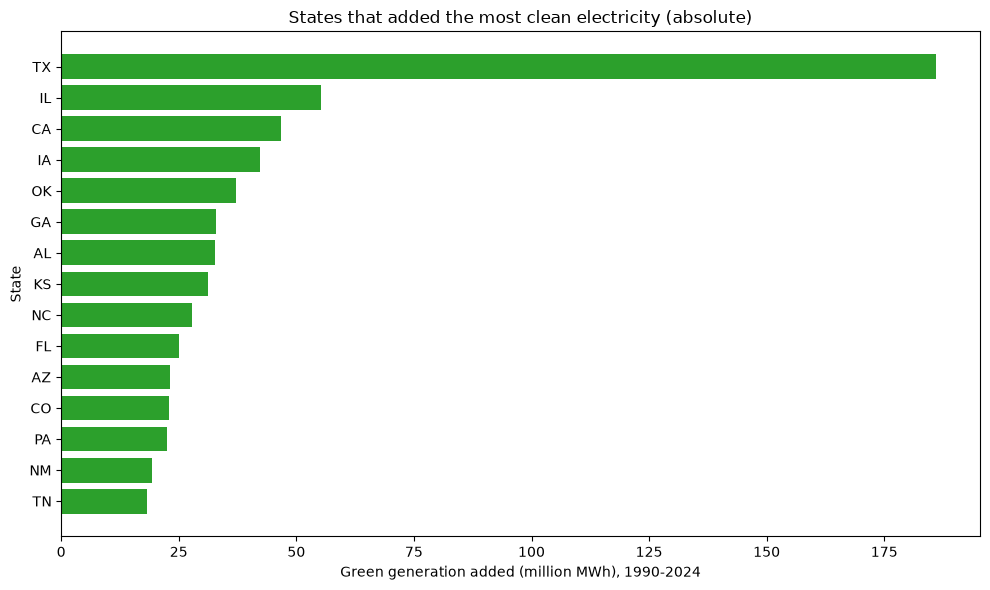

In [23]:
top15 = green_change.head(15)

plt.figure(figsize=(10, 6))
plt.barh(top15["STATE"], top15["GREEN_ADDED"] / 1_000_000, color="#2ca02c")
plt.xlabel("Green generation added (million MWh), 1990-2024")
plt.ylabel("State")
plt.title("States that added the most clean electricity (absolute)")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

## 9. Analysis #3 - Green Energy Share over Time

The two analyses are snapshots. Let's show the yearly trajectory for a few standout states:
Texas (wind boom), Iowa (proportional leader), California (steady growth), West Virginia
(coal country, stays low), and Connecticut (nuclear-heavy, declines).

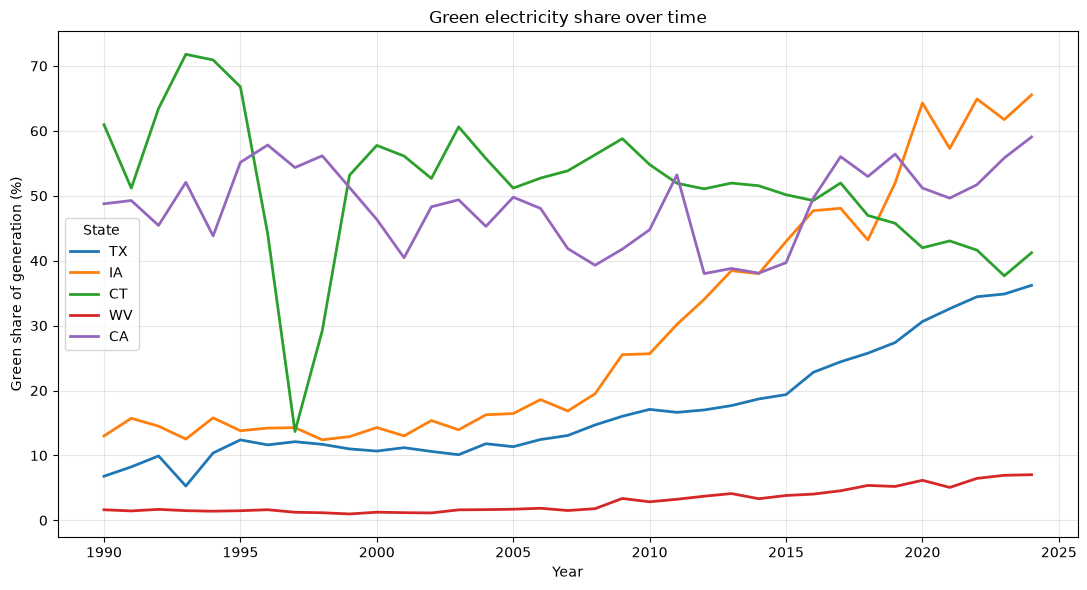

In [24]:
states_to_plot = ["TX", "IA", "CT", "WV", "CA"]

plt.figure(figsize=(11, 6))

for st in states_to_plot:
    data = pivot[pivot["STATE"] == st].sort_values("YEAR")
    plt.plot(data["YEAR"], data["GREEN_SHARE"] * 100, label=st, linewidth=2)

plt.xlabel("Year")
plt.ylabel("Green share of generation (%)")
plt.title("Green electricity share over time")
plt.legend(title="State")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 10. Export the cleaned data

Save the full state-year table for use in the Power BI dashboard (map + time series visuals).

In [25]:
pivot.to_csv("clean_state_green.csv", index=False)
print("Saved clean_state_green.csv:", pivot.shape)

Saved clean_state_green.csv: (1785, 6)


## 11. Build the per-state summary table

The dashboard's ranking charts need one row per state. Build a summary
with the two analyses plus a third, size-adjusted metric.

In [26]:
# Index by state so the columns align on subtraction
y1990 = pivot[pivot["YEAR"] == 1990].set_index("STATE")
y2024 = pivot[pivot["YEAR"] == 2024].set_index("STATE")

summary = pd.DataFrame({
    "PP_CHANGE": y2024["GREEN_SHARE"] - y1990["GREEN_SHARE"],
    "MWH_ADDED": y2024["Green"] - y1990["Green"],
    "SHARE_1990": y1990["GREEN_SHARE"],
    "SHARE_2024": y2024["GREEN_SHARE"],
})

#  Green energy added relative to total energy generation
summary["MWH_ADDED_PER_TOTAL"] = summary["MWH_ADDED"] / y2024["TOTAL"]

summary.sort_values("MWH_ADDED", ascending=False).head()

,PP_CHANGE,MWH_ADDED,SHARE_1990,SHARE_2024,MWH_ADDED_PER_TOTAL
STATE,,,,,
TX,0.294114,186052903.0,0.067918,0.362032,0.328343
IL,0.132010,55292453.0,0.557887,0.689897,0.299235
CA,0.102890,46811021.0,0.487699,0.590588,0.217372
IA,0.525518,42283705.0,0.129964,0.655482,0.600068
OK,0.363353,37189935.0,0.063778,0.427130,0.395234


It's worth keeping in mind the metric (`MWH_ADDED_PER_TOTAL`) deflates the big-state effect, but
it introduces its own issue. States whose total generation *decreased* (like Vermont after its
nuclear plant closed in 2014) received an inflated ratio as a result, because the denominator became smaller. So a
single straight-forward metric doesn't encompass the whole story. Each analysis reveals a different conclusion, and together these findings paint the bigger picture
of how each U.S. state is adopting green energy generation sources.

In [27]:
summary.to_csv("state_summary.csv", index=True)
print("Saved state_summary.csv:", summary.shape)

Saved state_summary.csv: (51, 5)


## Summary

Three analyses for three different conclusions:

- **By Green Energy Share Change:** Iowa, New Mexico, Kansas: proportional transformation, favors small grids
- **By Absolute MWh Added:** Texas, Illinois, California: real-world impact, favors large grids
- **By Size-Adjusted Added:** different again, but distorted by states whose total energy generation decreased (e.g., closing of nuclear plants)

The main conclusion is that *the metric you pick can influence who "wins"*.

Next steps: join EIA CO2 emissions data to test whether greener grids actually have lower emissions, and if not, why?

## 12. Part 2: Carbon Emissions

To see the extent of decarbonization, we must also analyze the CO2 emissions. In theory, bringing in renewable energy generation sources should
mean less CO2 in the air (so long as additional non-renewable sources aren't introduced). To test that, we can bring in EIA's CO2 emissions data and join it to the generation table.

The emissions file is structured the same way as the generation file, so putting it all together will be similar to everything before.

Data source: EIA, Emissions by State (https://www.eia.gov/electricity/data/state/)

In [28]:
import pandas as pd

emissions = pd.read_excel("emission_annual.xlsx", sheet_name="State Emissions")

emissions.info()
emissions.head()

co2_col = [c for c in emissions.columns if "CO2" in c][0]

emissions = emissions.rename(columns={
    co2_col: "CO2",
    "Year": "YEAR",
    "State": "STATE",
})

print(emissions["CO2"].head())

<class 'pandas.DataFrame'>
RangeIndex: 50534 entries, 0 to 50533
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype
---  ------             --------------  -----
 0   Year               50534 non-null  int64
 1   State              50534 non-null  str  
 2   Producer Type      50534 non-null  str  
 3   Energy Source      50534 non-null  str  
 4   CO2
(Metric Tons)  50534 non-null  int64
 5   SO2
(Metric Tons)  50534 non-null  int64
 6   NOx
(Metric Tons)  50534 non-null  int64
dtypes: int64(4), str(3)
memory usage: 2.7 MB
0    824004
1    821929
2      2075
3         0
4         0
Name: CO2, dtype: int64


Same idea as Part 1: keep only "Total Electric Power Industry" to avoid
double-counting, and keep only the "All Sources" rows since I want each state's total CO2.

In [29]:
emissions = emissions[
    (emissions["Producer Type"] == "Total Electric Power Industry")
    & (emissions["Energy Source"] == "All Sources")]

emissions = emissions[["YEAR", "STATE", "CO2"]]

emissions.head()

,YEAR,STATE,CO2
17,1990,AK,4208809
38,1990,AL,52936063
59,1990,AR,23425802
79,1990,AZ,33111213
115,1990,CA,52655643


## 13. Merging Emissions to Energy Generation

Now to join emissions to the green energy generation dataset, merging the YEAR and STATE columns to match.

In [30]:
combined = pd.merge(pivot, emissions, on=["YEAR", "STATE"], how="inner")

print("Combined shape:", combined.shape)
combined.head()

Combined shape: (1785, 7)


,YEAR,STATE,Green,Non-Green,TOTAL,GREEN_SHARE,CO2
0,1990,AK,1125556.0,4473950.0,5599506.0,0.201010,4208809
1,1990,AL,24565739.0,55086394.0,79652133.0,0.308413,52936063
2,1990,AR,16190139.0,22866487.0,39056626.0,0.414530,23425802
3,1990,AZ,28123153.0,34401377.0,62524530.0,0.449794,33111213
4,1990,CA,80372078.0,84426579.0,164798657.0,0.487699,52655643


## 14. Calculating Carbon Intensity

To enable comparison between green energy sources and carbon emissions, let's create a **carbon
intensity** metric: CO2 emitted per MWh generated. This normalizes for state size, so a small clean
state and a big clean state are on the same footing, and it can be compared directly against
green energy share.

West Virginia (coal state) should be high, Vermont (almost no non-renewable energy generation) should be quite low, near zero.

In [31]:
combined["CARBON_INTENSITY"] = combined["CO2"] / combined["TOTAL"]

check = combined[combined["YEAR"] == 2022][["STATE", "GREEN_SHARE", "CARBON_INTENSITY"]]
print(check[check["STATE"].isin(["WV", "VT"])].to_string(index=False))

STATE  GREEN_SHARE  CARBON_INTENSITY
   VT     0.996899          0.005847
   WV     0.064653          0.888814


## 15. Does a Greener State equate to a Cleaner State?

This scatter plots green energy generation share against the carbon intensity we calculated above, one dot per
state, for a single year (let's say, 2024). If a cleaner mix really means lower emissions, the line should
slope downward. 

From the data, we can determine a correlation coeeficient to quantify the relationship between the two variables.

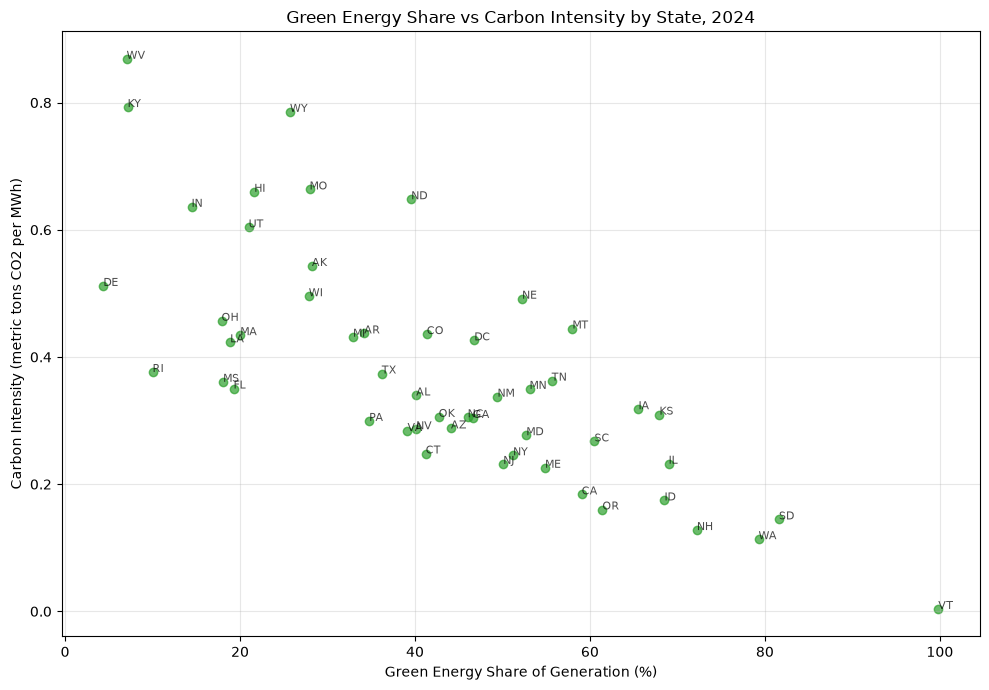

Correlation between green share and carbon intensity (2024): -0.76


In [32]:
year = 2024
snapshot = combined[combined["YEAR"] == year]

plt.figure(figsize=(10, 7))
plt.scatter(
    snapshot["GREEN_SHARE"] * 100,
    snapshot["CARBON_INTENSITY"],
    color="#2ca02c",
    alpha=0.7,
)

for _, row in snapshot.iterrows():
    plt.annotate(
        row["STATE"],
        (row["GREEN_SHARE"] * 100, row["CARBON_INTENSITY"]),
        fontsize=8,
        alpha=0.7,
    )

plt.xlabel("Green Energy Share of Generation (%)")
plt.ylabel("Carbon Intensity (metric tons CO2 per MWh)")
plt.title(f"Green Energy Share vs Carbon Intensity by State, {year}")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


corr = snapshot["GREEN_SHARE"].corr(snapshot["CARBON_INTENSITY"])

print(f"Correlation between green share and carbon intensity ({year}): {corr:.2f}")

## 16. Export the Carbon Emissions Data

Save the combined dataset for use in the Power BI dashboard.

In [33]:
combined.to_csv("clean_state_emissions.csv", index=False)
print("Saved clean_state_emissions.csv:", combined.shape)

Saved clean_state_emissions.csv: (1785, 8)


## 17. Export National Trend Data

Last minute, I realized it would be a good idea to show how the national carbon emissions and green energy generation investments have changed over time.

In [34]:
national = combined.groupby("YEAR").agg(
    green=("Green","sum"),
    total=("TOTAL","sum"),
    co2=("CO2","sum"),
).reset_index()
national["GREEN_SHARE"] = national["green"] / national["total"]
national["CARBON_INTENSITY"] = national["co2"] / national["total"]
national.to_csv("national_trend.csv", index=False)